# PhysioNet EEGNet utility-aware iterative feature masking

Corrected experiment:

- EEGNet is trained in each outer subject fold.
- The latent EEGNet embedding is extracted before the final Dense layer.
- Utility-aware iterative masking is applied to that embedding.
- The original trained EEGNet Dense head evaluates masked utility.
- A Logistic Regression attacker evaluates identity from the same embedding.
- Runs 4 and 8 are training recordings; run 12 is the held-out recording.

In [3]:
from google.colab import drive
drive.mount("/content/drive")
get_ipython().system('pip -q install "scikit-learn>=1.4,<2" matplotlib')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import gc
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import constraints, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 42
TRAIN_RUNS = [4, 8]
TEST_RUN = 12
N_FOLDS = 5
N_RANKING_MODELS = 3
MASK_PERCENTAGES = [0, 10, 20, 30, 40, 50, 60, 70, 80]

DRIVE_ROOT = Path("/content/drive/MyDrive/URV_Datasets")
PHYSIONET_DIR = DRIVE_ROOT / "PhysioNet_MI"
CACHE_DIR = PHYSIONET_DIR / "eegnet_embedding_masking_cache"
RESULTS_DIR = PHYSIONET_DIR / "results"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

NPZ_CANDIDATES = [
    DRIVE_ROOT / "physionet_mi_lr_imagery_subjects_1_50_with_runs.npz",
    PHYSIONET_DIR / "processed" / "physionet_mi_lr_imagery_subjects_1_50_with_runs.npz",
    PHYSIONET_DIR / "processed" / "physionet_mi_lr_imagery_subjects_1_50.npz",
]

DETAIL_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_detailed.csv"
SUMMARY_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_summary.csv"
TRADEOFF_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_tradeoff.csv"
SELECTION_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_selections.csv"
BASELINE_FILE = RESULTS_DIR / "physionet_eegnet_fold_baselines.csv"
FIGURE_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_tradeoff.png"
RUN_FILE = RESULTS_DIR / "physionet_eegnet_improved_masking_run.json"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(SEED)
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus)
assert gpus, "No GPU detected. In Colab select Runtime > Change runtime type > T4 GPU."

dataset_path = next((path for path in NPZ_CANDIDATES if path.exists()), None)
assert dataset_path is not None, (
    "Could not find the PhysioNet 1-50 NPZ. Checked:\n" +
    "\n".join(str(path) for path in NPZ_CANDIDATES)
)
print("Dataset:", dataset_path)

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset: /content/drive/MyDrive/URV_Datasets/physionet_mi_lr_imagery_subjects_1_50_with_runs.npz


## 1. Load and validate PhysioNet epochs

In [5]:
data = np.load(dataset_path, allow_pickle=True)
print("NPZ keys:", data.files)

X_raw = data["X"].astype(np.float32)
y_utility = data["y"].astype(np.int64)

if "subject_ids" in data.files:
    subject_ids = data["subject_ids"].astype(np.int64)
elif "subjects" in data.files:
    subject_ids = data["subjects"].astype(np.int64)
else:
    raise KeyError("The NPZ contains no subject_ids/subjects array.")

if "run_ids" in data.files:
    run_ids = data["run_ids"].astype(np.int64)
else:
    print("run_ids missing; validating ordered 30-trial run blocks...")
    run_ids = np.empty(len(subject_ids), dtype=np.int64)
    for subject in np.unique(subject_ids):
        idx = np.flatnonzero(subject_ids == subject)
        assert len(idx) == 90, (
            f"Subject {subject} has {len(idx)} trials; cannot infer run IDs safely."
        )
        assert np.array_equal(idx, np.arange(idx.min(), idx.max() + 1))
        for block, run in enumerate([4, 8, 12]):
            block_idx = idx[block * 30:(block + 1) * 30]
            labels, counts = np.unique(y_utility[block_idx], return_counts=True)
            assert set(labels.tolist()) == {0, 1}
            assert counts.min() == counts.max() == 15
            run_ids[block_idx] = run

assert X_raw.ndim == 3
assert len(X_raw) == len(y_utility) == len(subject_ids) == len(run_ids)
assert len(np.unique(subject_ids)) == 50
assert set(np.unique(run_ids).tolist()) == {4, 8, 12}
assert set(np.unique(y_utility).tolist()) == {0, 1}

if X_raw.shape[-1] == 641:
    X_raw = X_raw[..., :640]
assert X_raw.shape[-1] == 640, X_raw.shape

print("Epochs:", X_raw.shape)
print("Utility labels:", dict(zip(*np.unique(y_utility, return_counts=True))))
print("Runs:", dict(zip(*np.unique(run_ids, return_counts=True))))
print("Subjects:", len(np.unique(subject_ids)))

NPZ keys: ['X', 'y', 'subject_ids', 'run_ids']
Epochs: (2245, 64, 640)
Utility labels: {np.int64(0): np.int64(1132), np.int64(1): np.int64(1113)}
Runs: {np.int64(4): np.int64(750), np.int64(8): np.int64(747), np.int64(12): np.int64(748)}
Subjects: 50


## 2. Original EEGNet architecture and embedding extraction

In [6]:
def zscore_per_trial_channel(X, eps=1e-6):
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    return ((X - mean) / (std + eps)).astype(np.float32)


def build_eegnet_binary(n_channels, n_samples, n_classes=2, dropout_rate=0.5):
    inputs = layers.Input(shape=(n_channels, n_samples, 1), name="eeg_input")

    x = layers.Conv2D(8, (1, 64), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.DepthwiseConv2D(
        (n_channels, 1),
        use_bias=False,
        depth_multiplier=2,
        depthwise_constraint=constraints.max_norm(1.0),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.SeparableConv2D(16, (1, 16), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout_rate)(x)

    embedding = layers.Flatten(name="eegnet_embedding")(x)
    outputs = layers.Dense(
        n_classes,
        activation="softmax",
        kernel_constraint=constraints.max_norm(0.25),
        name="utility_head",
    )(embedding)
    return models.Model(inputs, outputs)


def train_or_load_fold_eegnet(fold, utility_train_idx):
    cache_file = CACHE_DIR / f"fold_{fold}_eegnet_embeddings.npz"
    history_file = CACHE_DIR / f"fold_{fold}_eegnet_history.json"

    if cache_file.exists():
        print(f"Fold {fold}: loading cached EEGNet embeddings...")
        cached = np.load(cache_file, allow_pickle=False)
        return (
            cached["embeddings"],
            cached["dense_kernel"],
            cached["dense_bias"],
            cache_file,
        )

    print(f"Fold {fold}: training EEGNet on T4 GPU...")
    set_seed(SEED + fold)
    tf.keras.backend.clear_session()

    X_train = zscore_per_trial_channel(X_raw[utility_train_idx])[..., np.newaxis]
    y_train = y_utility[utility_train_idx]
    y_train_cat = to_categorical(y_train, num_classes=2)

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train,
        y_train_cat,
        test_size=0.20,
        random_state=SEED + fold,
        stratify=y_train,
    )

    model = build_eegnet_binary(
        n_channels=X_raw.shape[1],
        n_samples=X_raw.shape[2],
        n_classes=2,
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks = [
        EarlyStopping(
            monitor="val_accuracy", patience=20, restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5
        ),
    ]
    history = model.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=callbacks,
        verbose=2,
    )

    embedding_model = models.Model(
        model.input, model.get_layer("eegnet_embedding").output
    )
    X_all_norm = zscore_per_trial_channel(X_raw)[..., np.newaxis]
    embeddings = embedding_model.predict(X_all_norm, batch_size=128, verbose=1)
    dense_kernel, dense_bias = model.get_layer("utility_head").get_weights()

    np.savez_compressed(
        cache_file,
        embeddings=embeddings.astype(np.float32),
        dense_kernel=dense_kernel.astype(np.float32),
        dense_bias=dense_bias.astype(np.float32),
    )
    with open(history_file, "w") as handle:
        json.dump(
            {key: [float(value) for value in values]
             for key, values in history.history.items()},
            handle,
            indent=2,
        )

    del model, embedding_model, X_train, X_fit, X_val, y_fit, y_val, X_all_norm
    gc.collect()
    return embeddings, dense_kernel, dense_bias, cache_file


def dense_head_predict(embeddings, kernel, bias):
    logits = embeddings @ kernel + bias
    logits = logits - logits.max(axis=1, keepdims=True)
    probabilities = np.exp(logits)
    probabilities /= probabilities.sum(axis=1, keepdims=True)
    return np.argmax(probabilities, axis=1)

## 3. Utility-aware iterative embedding masking helpers

In [7]:
def score_metrics(y_true, prediction):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "weighted_f1": f1_score(y_true, prediction, average="weighted"),
    }


def stable_importance(X_train, y_train, seed_offset):
    importances = []
    for repeat in range(N_RANKING_MODELS):
        ranker = RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=SEED + seed_offset + repeat,
            n_jobs=-1,
        )
        ranker.fit(X_train, y_train)
        importances.append(ranker.feature_importances_)
    return np.mean(importances, axis=0)


def make_privacy_attacker():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED,
        )),
    ])


def evaluate_masked_embedding(
    embeddings,
    dense_kernel,
    dense_bias,
    fold,
    utility_test_idx,
    privacy_train_idx,
    privacy_test_idx,
    percentage,
    n_masked,
):
    rows = []

    utility_prediction = dense_head_predict(
        embeddings[utility_test_idx], dense_kernel, dense_bias
    )
    rows.append({
        "fold": fold,
        "mask_percentage": percentage,
        "n_masked": n_masked,
        "task": "utility",
        "direction": "EEGNet: runs 4,8 training subjects -> run 12 unseen subjects",
        "n_classes": 2,
        "chance_accuracy": 0.5,
        **score_metrics(y_utility[utility_test_idx], utility_prediction),
    })

    encoder = LabelEncoder()
    encoder.fit(subject_ids[privacy_train_idx])
    y_privacy_train = encoder.transform(subject_ids[privacy_train_idx])
    y_privacy_test = encoder.transform(subject_ids[privacy_test_idx])

    attacker = make_privacy_attacker()
    attacker.fit(embeddings[privacy_train_idx], y_privacy_train)
    privacy_prediction = attacker.predict(embeddings[privacy_test_idx])
    rows.append({
        "fold": fold,
        "mask_percentage": percentage,
        "n_masked": n_masked,
        "task": "privacy",
        "direction": "runs 4,8 -> run 12 subject ID",
        "n_classes": len(encoder.classes_),
        "chance_accuracy": 1 / len(encoder.classes_),
        **score_metrics(y_privacy_test, privacy_prediction),
    })
    return rows

## 4. Five EEGNet folds and iterative latent-feature masking

Each fold contains 40 EEGNet-training subjects and 10 unseen evaluation
subjects. EEGNet is trained only on runs 4 and 8 from the 40 training subjects.
The feature mask is also designed only from those training subjects.

In [8]:
unique_subjects = np.unique(subject_ids)
outer_cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

all_rows = []
selection_rows = []
baseline_rows = []

for fold, (train_subject_pos, test_subject_pos) in enumerate(
    outer_cv.split(unique_subjects), start=1
):
    train_subjects = unique_subjects[train_subject_pos]
    test_subjects = unique_subjects[test_subject_pos]

    utility_train_idx = np.flatnonzero(
        np.isin(subject_ids, train_subjects) & np.isin(run_ids, TRAIN_RUNS)
    )
    utility_test_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & (run_ids == TEST_RUN)
    )
    privacy_train_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & np.isin(run_ids, TRAIN_RUNS)
    )
    privacy_test_idx = np.flatnonzero(
        np.isin(subject_ids, test_subjects) & (run_ids == TEST_RUN)
    )

    assert set(subject_ids[utility_train_idx]).isdisjoint(
        set(subject_ids[utility_test_idx])
    )
    assert set(subject_ids[privacy_train_idx]) == set(subject_ids[privacy_test_idx])

    embeddings, dense_kernel, dense_bias, embedding_cache = (
        train_or_load_fold_eegnet(fold, utility_train_idx)
    )
    assert len(embeddings) == len(X_raw)
    assert embeddings.shape[1] == dense_kernel.shape[0]
    print(f"Fold {fold}: embedding shape {embeddings.shape}")

    design_subject_encoder = LabelEncoder()
    design_subject_labels = design_subject_encoder.fit_transform(
        subject_ids[utility_train_idx]
    )
    train_means = embeddings[utility_train_idx].mean(axis=0)
    masked_embeddings = embeddings.copy()
    selected = []
    n_features = embeddings.shape[1]

    for percentage in MASK_PERCENTAGES:
        target_count = int(round(n_features * percentage / 100.0))
        if target_count > len(selected):
            privacy_importance = stable_importance(
                masked_embeddings[utility_train_idx],
                design_subject_labels,
                seed_offset=fold * 100,
            )
            utility_importance = stable_importance(
                masked_embeddings[utility_train_idx],
                y_utility[utility_train_idx],
                seed_offset=fold * 100 + 50,
            )
            regularizer = 0.10 * np.mean(utility_importance)
            mask_score = privacy_importance / (utility_importance + regularizer)
            mask_score[np.asarray(selected, dtype=np.int64)] = -np.inf

            number_to_add = target_count - len(selected)
            new_features = np.argsort(mask_score)[::-1][:number_to_add]
            for feature_index in new_features:
                selection_rows.append({
                    "fold": fold,
                    "selected_at_percentage": percentage,
                    "selection_order": len(selected) + 1,
                    "embedding_index": int(feature_index),
                    "privacy_importance": float(privacy_importance[feature_index]),
                    "utility_importance": float(utility_importance[feature_index]),
                    "mask_score": float(mask_score[feature_index]),
                })
                selected.append(int(feature_index))
            masked_embeddings[:, new_features] = train_means[new_features]

        print(
            f"Fold {fold}: mask={percentage}% "
            f"({len(selected)}/{n_features} embedding features)"
        )
        fold_rows = evaluate_masked_embedding(
            masked_embeddings,
            dense_kernel,
            dense_bias,
            fold,
            utility_test_idx,
            privacy_train_idx,
            privacy_test_idx,
            percentage,
            len(selected),
        )
        all_rows.extend(fold_rows)
        if percentage == 0:
            for row in fold_rows:
                baseline_rows.append({
                    **row,
                    "embedding_cache": str(embedding_cache),
                })

    del embeddings, masked_embeddings, dense_kernel, dense_bias
    gc.collect()

results = pd.DataFrame(all_rows)
selections = pd.DataFrame(selection_rows)
baselines = pd.DataFrame(baseline_rows)

Fold 1: training EEGNet on T4 GPU...
Epoch 1/150
30/30 - 19s - 625ms/step - accuracy: 0.4953 - loss: 0.7008 - val_accuracy: 0.4917 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/150
30/30 - 1s - 22ms/step - accuracy: 0.5099 - loss: 0.6928 - val_accuracy: 0.4667 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/150
30/30 - 1s - 19ms/step - accuracy: 0.5402 - loss: 0.6873 - val_accuracy: 0.4917 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/150
30/30 - 1s - 22ms/step - accuracy: 0.5413 - loss: 0.6876 - val_accuracy: 0.5292 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 5/150
30/30 - 1s - 19ms/step - accuracy: 0.5423 - loss: 0.6871 - val_accuracy: 0.5292 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 6/150
30/30 - 1s - 19ms/step - accuracy: 0.5601 - loss: 0.6836 - val_accuracy: 0.5167 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 7/150
30/30 - 1s - 20ms/step - accuracy: 0.5569 - loss: 0.6817 - val_accuracy: 0.5417 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 8/150
30/3

## 5. Baseline-relative results and privacy-utility trade-off

,mask_percentage,n_masked,balanced_accuracy_mean_utility,utility_loss_mean_utility,balanced_accuracy_mean_privacy,privacy_reduction_mean_privacy,normalized_privacy_reduction_mean_privacy
0,0,0,0.666064,0.000000,0.641048,0.000000,0.000000
1,10,32,0.662206,0.003858,0.634476,0.006571,0.014607
2,20,64,0.670245,-0.004180,0.614381,0.026667,0.048662
3,30,96,0.671524,-0.005460,0.610095,0.030952,0.056152
4,40,128,0.671543,-0.005479,0.579333,0.061714,0.115450
5,50,160,0.671527,-0.005462,0.549810,0.091238,0.172538
6,60,192,0.674140,-0.008076,0.546000,0.095048,0.175258
7,70,224,0.669946,-0.003882,0.499143,0.141905,0.259142
8,80,256,0.677877,-0.011813,0.471048,0.170000,0.310755


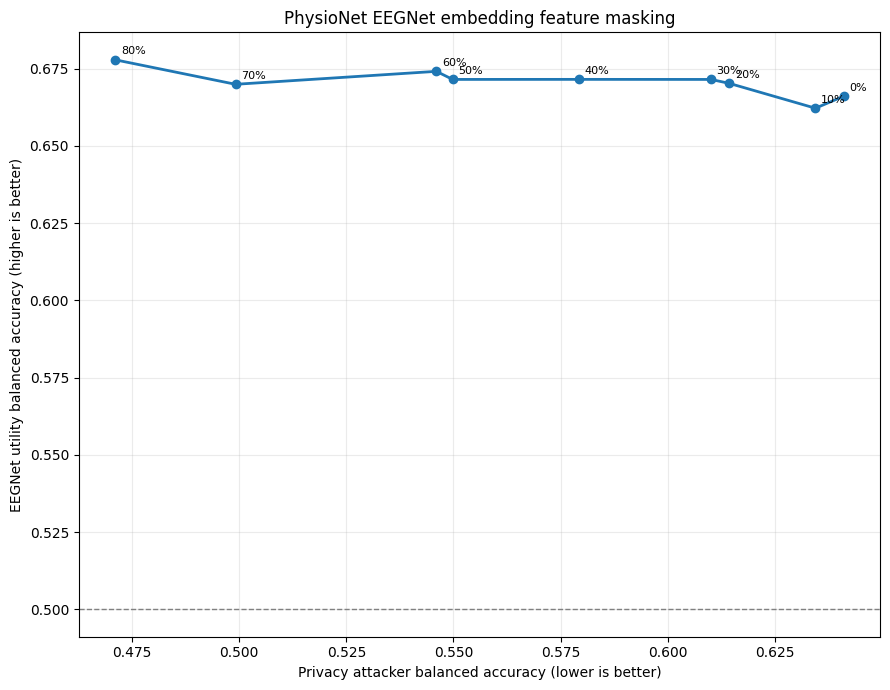

Saved EEGNet fold baselines: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_fold_baselines.csv
Saved detailed results: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_detailed.csv
Saved summary: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_summary.csv
Saved trade-off: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_tradeoff.csv
Saved selections: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_selections.csv
Saved figure: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_tradeoff.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_improved_masking_run.json


In [9]:
reference = results[results["mask_percentage"] == 0][
    ["fold", "task", "balanced_accuracy", "chance_accuracy"]
].rename(columns={
    "balanced_accuracy": "baseline_balanced_accuracy",
    "chance_accuracy": "baseline_chance_accuracy",
})
results = results.merge(reference, on=["fold", "task"], how="left")

results["utility_loss"] = np.where(
    results["task"] == "utility",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)
results["privacy_reduction"] = np.where(
    results["task"] == "privacy",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)
denominator = results["baseline_balanced_accuracy"] - results["baseline_chance_accuracy"]
results["normalized_privacy_reduction"] = np.where(
    (results["task"] == "privacy") & (denominator > 0),
    results["privacy_reduction"] / denominator,
    np.nan,
)

summary = (
    results
    .groupby(["mask_percentage", "n_masked", "task"], as_index=False)
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        chance_accuracy_mean=("chance_accuracy", "mean"),
        utility_loss_mean=("utility_loss", "mean"),
        privacy_reduction_mean=("privacy_reduction", "mean"),
        normalized_privacy_reduction_mean=("normalized_privacy_reduction", "mean"),
        n_evaluations=("balanced_accuracy", "count"),
    )
)

utility_summary = summary[summary["task"] == "utility"].drop(columns="task")
privacy_summary = summary[summary["task"] == "privacy"].drop(columns="task")
tradeoff = utility_summary.merge(
    privacy_summary,
    on=["mask_percentage", "n_masked"],
    suffixes=("_utility", "_privacy"),
)

results.to_csv(DETAIL_FILE, index=False)
summary.to_csv(SUMMARY_FILE, index=False)
tradeoff.to_csv(TRADEOFF_FILE, index=False)
selections.to_csv(SELECTION_FILE, index=False)
baselines.to_csv(BASELINE_FILE, index=False)

display(tradeoff[[
    "mask_percentage",
    "n_masked",
    "balanced_accuracy_mean_utility",
    "utility_loss_mean_utility",
    "balanced_accuracy_mean_privacy",
    "privacy_reduction_mean_privacy",
    "normalized_privacy_reduction_mean_privacy",
]])

plt.figure(figsize=(9, 7))
plt.plot(
    tradeoff["balanced_accuracy_mean_privacy"],
    tradeoff["balanced_accuracy_mean_utility"],
    marker="o",
    linewidth=2,
)
for row in tradeoff.itertuples(index=False):
    plt.annotate(
        f"{row.mask_percentage}%",
        (row.balanced_accuracy_mean_privacy,
         row.balanced_accuracy_mean_utility),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Privacy attacker balanced accuracy (lower is better)")
plt.ylabel("EEGNet utility balanced accuracy (higher is better)")
plt.title("PhysioNet EEGNet embedding feature masking")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

run_summary = {
    "dataset": "PhysioNet EEG Motor Movement/Imagery, subjects 1-50",
    "utility_model": "EEGNet with original trained Dense utility head",
    "masked_representation": "EEGNet latent embedding before Dense head",
    "method": "utility-aware stability-averaged iterative feature masking",
    "normalization": "per-trial per-channel z-score",
    "train_runs": TRAIN_RUNS,
    "test_run": TEST_RUN,
    "outer_subject_folds": N_FOLDS,
    "ranking_models_per_task_per_step": N_RANKING_MODELS,
    "mask_percentages": MASK_PERCENTAGES,
    "dataset_path": str(dataset_path),
    "files": {
        "fold_baselines": str(BASELINE_FILE),
        "detailed": str(DETAIL_FILE),
        "summary": str(SUMMARY_FILE),
        "tradeoff": str(TRADEOFF_FILE),
        "selections": str(SELECTION_FILE),
        "figure": str(FIGURE_FILE),
    },
}
with open(RUN_FILE, "w") as handle:
    json.dump(run_summary, handle, indent=2)

print("Saved EEGNet fold baselines:", BASELINE_FILE)
print("Saved detailed results:", DETAIL_FILE)
print("Saved summary:", SUMMARY_FILE)
print("Saved trade-off:", TRADEOFF_FILE)
print("Saved selections:", SELECTION_FILE)
print("Saved figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)